# Spatial cross-validation — when random CV lies

> ▶ **Companion deck:** `src/07-evaluation.md` — *Spatial Cross-Validation*

When data carry **spatial autocorrelation**, random *k*-fold CV creates a
fundamental problem — **information leakage**:

- **Train and test folds contain nearby locations** that share information.
- This makes predictions appear **easier than they really are**.
- The model gets "hints" about test data through spatially correlated neighbours,
  violating the **independence assumption** that CV relies on.

This notebook reproduces the deck's worked example end-to-end: we score **one**
linear model **four** ways on the canonical **Meuse** soil dataset. *Only the
split changes* — so any gap in the scores is caused by the split geometry alone.

## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import verde as vd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, GroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

%matplotlib inline
%config InlineBackend.figure_format = "retina" 

## The data — Meuse (n = 155)

The **`meuse`** dataset is the canonical geostatistics teaching set: heavy-metal
soil samples in a flood plain of the river Meuse near Stein (NL). It ships with
R's `sp`/`gstat` and is the same point dataset the course uses for variograms and
kriging (deck 05, notebook `02b_variograms`). Provenance: Pebesma (2004), *gstat*.

Following the deck, we predict **`log(zinc)`** from **distance-to-river (`dist`)**
and **elevation (`elev`)**. The coordinates `x`, `y` are projected (metres), so
block **spacing is expressed in metres**.

In [2]:
df = pd.read_csv("data/meuse/meuse.csv")
df["log_zinc"] = np.log(df["zinc"])

X = df[["dist", "elev"]].to_numpy()          # predictors
y = df["log_zinc"].to_numpy()                # target
coords = df[["x", "y"]].to_numpy()           # (n, 2): easting, northing (m)

print(f"n = {len(df)} samples")
df[["x", "y", "dist", "elev", "zinc", "log_zinc"]].head()

n = 155 samples


,x,y,dist,elev,zinc,log_zinc
0,181072,333611,0.001358,7.909,1022,6.929517
1,181025,333558,0.012224,6.983,1141,7.039660
2,181165,333537,0.103029,7.800,640,6.461468
3,181298,333484,0.190094,7.655,257,5.549076
4,181307,333330,0.277090,7.480,269,5.594711


## Why random folds leak — see it on the map

The problem is easiest to *see*. A **random** 5-fold split scatters neighbours
across folds, so almost every held-out point sits right next to a training point
of another fold. A **500 m block** split holds contiguous chunks of space out
together, so a test block has no training point inside it.

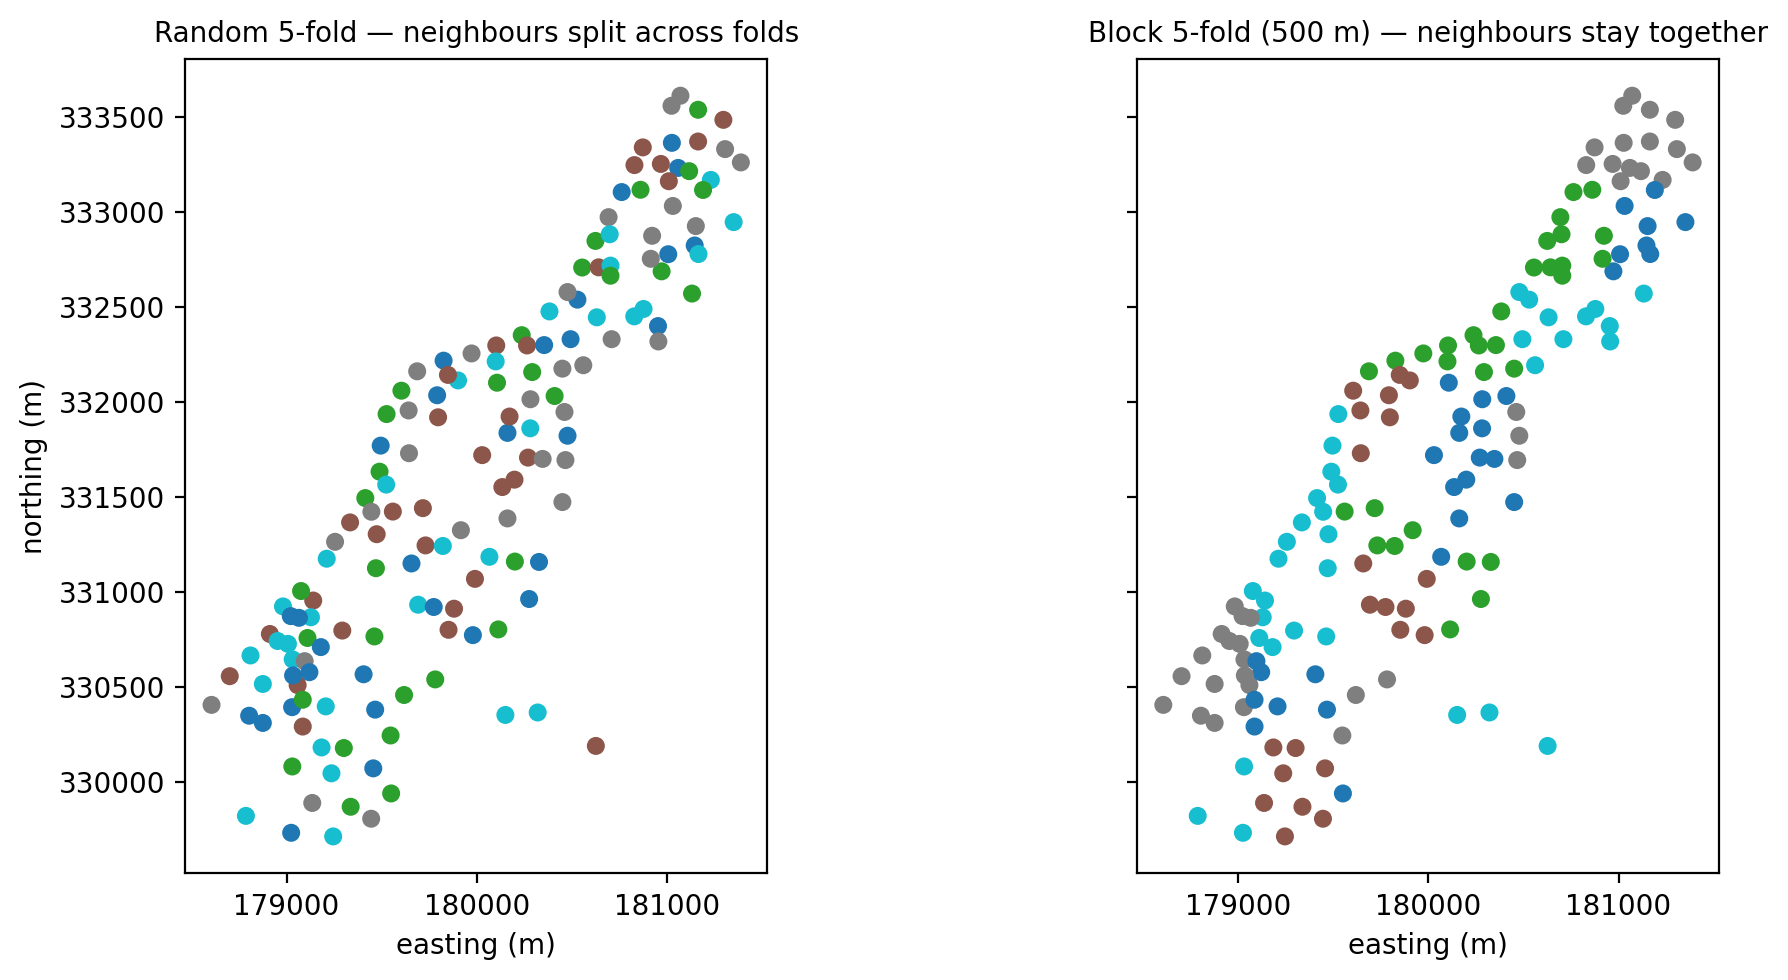

In [3]:
rand  = KFold(n_splits=5, shuffle=True, random_state=0)
block = vd.BlockKFold(spacing=500, n_splits=5, shuffle=True, random_state=0)

def fold_labels(splitter, split_arg):
    lab = np.empty(len(df), dtype=int)
    for k, (_, te) in enumerate(splitter.split(split_arg)):
        lab[te] = k
    return lab

panels = [("Random 5-fold — neighbours split across folds", fold_labels(rand, X)),
          ("Block 5-fold (500 m) — neighbours stay together", fold_labels(block, coords))]

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
for ax, (title, lab) in zip(axes, panels):
    ax.scatter(coords[:, 0], coords[:, 1], c=lab, cmap="tab10", s=30)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("easting (m)"); ax.set_aspect("equal")
axes[0].set_ylabel("northing (m)")
plt.tight_layout(); plt.show()

In the left panel every colour is sprinkled across the whole extent — each test
point has a same-neighbourhood training point of another colour beside it, and
that neighbour quietly leaks the answer. In the right panel the colours form
contiguous patches, so an entire block is genuinely unseen at prediction time.

> **Lesson —** random folds mix neighbours across train and test; only a
> space-aware split reproduces the honest task of predicting an *unseen* place.

## One model, four splits — the worked example

We hold the model fixed (`LinearRegression` on `dist` + `elev`) and change only
the cross-validator. `cv_report` returns, over the folds, the mean RMSE, mean
MAE, mean $R^2$, and the **spread** of $R^2$ (its standard deviation) — the
spread tells us how *unevenly* the model transfers across space.

In [4]:
def cv_report(splits):                 # mean + R^2 spread over folds
    rmse, mae, r2 = [], [], []
    for tr, te in splits:
        m = LinearRegression().fit(X[tr], y[tr]); p = m.predict(X[te])
        rmse.append(mean_squared_error(y[te], p) ** 0.5)
        mae.append(mean_absolute_error(y[te], p)); r2.append(r2_score(y[te], p))
    return np.mean(rmse), np.mean(mae), np.mean(r2), np.std(r2)

The four cross-validators — only the split *geometry* differs:

- **`KFold`** (random) — scattered points; the optimistic baseline.
- **`verde.BlockKFold` (500 m)** — whole 500 m blocks held out together; the honest split.
- **`verde.BlockShuffleSplit`** — many random *sets* of blocks; averages over
  block layouts, so the $R^2$ spread shrinks.
- **`GroupKFold`** on hand-rolled 500 m grid ids — the dependency-free **fallback**
  when `verde` is unavailable; leaves whole grid cells out.

In [5]:
random_cv = KFold(n_splits=5, shuffle=True, random_state=0)   # optimistic
block_cv  = vd.BlockKFold(spacing=500, n_splits=5,
                          shuffle=True, random_state=0)         # honest
block_ss  = vd.BlockShuffleSplit(spacing=500, n_splits=30,
                                 test_size=0.3, random_state=0)

# Fallback if verde missing: grid block ids, leave blocks out.
step = 500.0
bx = np.floor((df.x - df.x.min()) / step).astype(int)
by = np.floor((df.y - df.y.min()) / step).astype(int)
block_id = bx.astype(str) + "_" + by.astype(str)

rows = {
    "random 5-fold (KFold)":    cv_report(random_cv.split(X)),
    "verde.BlockKFold (500 m)": cv_report(block_cv.split(coords)),
    "verde.BlockShuffleSplit":  cv_report(block_ss.split(coords)),
    "GroupKFold (fallback)":    cv_report(GroupKFold(n_splits=5)
                                          .split(X, y, block_id)),
}
table = pd.DataFrame(rows, index=["RMSE", "MAE", "mean R2", "R2 sd"]).T.round(2)
table

,RMSE,MAE,mean R2,R2 sd
random 5-fold (KFold),0.43,0.34,0.62,0.13
verde.BlockKFold (500 m),0.45,0.36,0.40,0.35
verde.BlockShuffleSplit,0.45,0.36,0.58,0.09
GroupKFold (fallback),0.45,0.36,0.55,0.06


This is the deck's table. RMSE and MAE barely move (~0.43 → 0.45), but the
headline **mean $R^2$ collapses from 0.62 (random) to 0.40 (honest blocks)** —
and the block $R^2$ spread balloons to 0.35, exposing a model that transfers
*unevenly* across space. `BlockShuffleSplit` and `GroupKFold` land in between:
still honest about the level, but their averaging/gridding tightens the spread.

> **Lesson —** honest (block) CV collapses mean $R^2$ 0.62 → 0.40 — random CV
> flattered a model that transfers unevenly.

## Data-driven folds — clustering (extension)

The deck also covers **clustering-based** folds: rather than a regular grid, let
the data define the folds by clustering the observations (here on coordinates
with k-means) and holding out one whole cluster at a time. It reuses the exact
same `cv_report` — again only the split changes.

cluster folds  (np.float64(0.47), np.float64(0.4), np.float64(0.56), np.float64(0.15))


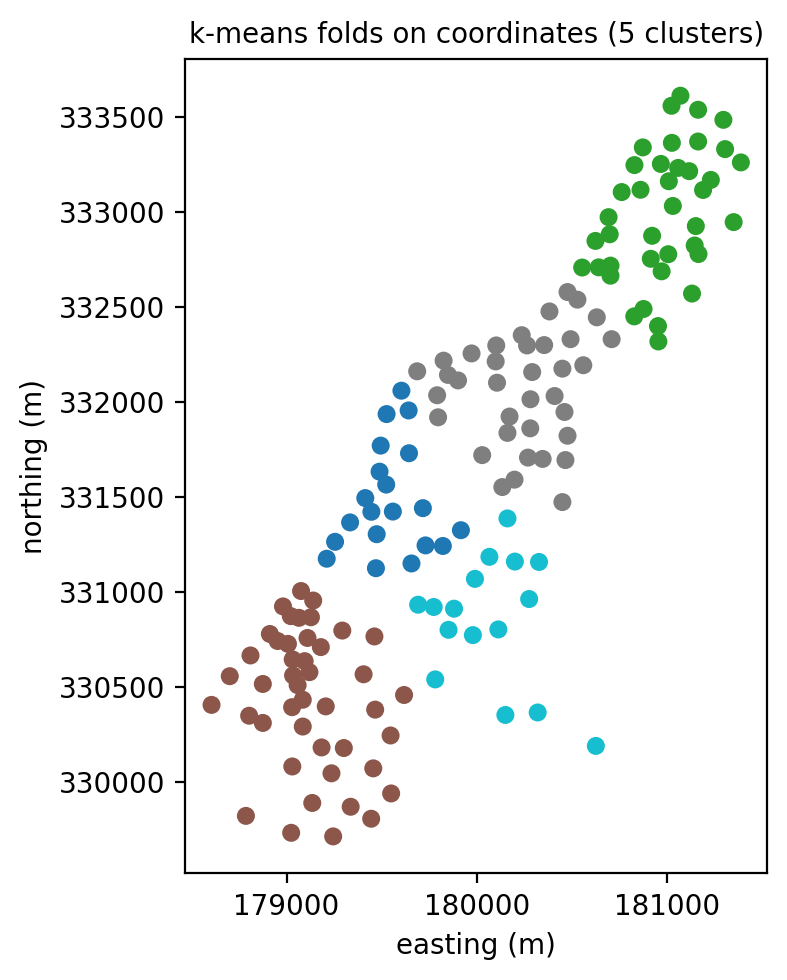

In [6]:
from sklearn.cluster import KMeans

clusters = KMeans(n_clusters=5, n_init="auto", random_state=0).fit_predict(coords)
print("cluster folds ",
      tuple(round(v, 2) for v in cv_report(GroupKFold(n_splits=5)
                                           .split(X, y, clusters))))

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(coords[:, 0], coords[:, 1], c=clusters, cmap="tab10", s=30)
ax.set_title("k-means folds on coordinates (5 clusters)", fontsize=10)
ax.set_xlabel("easting (m)"); ax.set_ylabel("northing (m)")
ax.set_aspect("equal"); plt.tight_layout(); plt.show()

The clusters are contiguous, spatially separated patches — like blocks but with
data-driven shapes — so the score sits close to the honest block figures, not the
optimistic random one. Covariate-based clustering (elevation, land cover) would
instead test transfer across *environmental* gradients.

> **Lesson —** any split that keeps neighbours together — grid blocks or data-driven
> clusters — recovers the honest score; the regular-grid geometry is not the point.

## Did the model absorb the spatial signal? Residual Moran's I

Point accuracy (RMSE/MAE/$R^2$) says *how big* the errors are; **Moran's I on the
residuals** says *whether what is left over is still spatially structured*. If
$I \approx 0$ the model absorbed the spatial signal; if $I > 0$ and significant,
there is **leftover autocorrelation** — folds are not independent and the model
is missing spatial process.

In [7]:
from libpysal.weights import KNN
from esda.moran import Moran

resid = y - LinearRegression().fit(X, y).predict(X)   # global-fit residuals
w = KNN.from_array(coords, k=8); w.transform = "r"
mi = Moran(resid, w)
print(f"residual Moran's I = {mi.I:.3f}   p = {mi.p_sim:.3f}")

residual Moran's I = 0.309   p = 0.001


$I \approx 0.31$ with $p = 0.001$: strong, significant **leftover** spatial
structure. `dist` + `elev` explain part of the zinc surface but not all of it —
which is exactly *why* nearby train points leak and random CV was optimistic.

> **Lesson —** significant residual Moran's I is the fingerprint of leakage risk;
> always check it before trusting any CV score on spatial data.

## Caveat — is spatial CV always the right yardstick?

Distance-aware CV is now standard practice, but its role for *map-accuracy
assessment* is genuinely debated — the honest answer depends on **how your data
were sampled** and **what you want to estimate**.

- **Probability sampling:** design-based validation on a held-out probability
  sample is unbiased, and spatial CV can be *pessimistic* — Wadoux, Heuvelink,
  de Bruin & Brus (2021), *Ecological Modelling* 457:109692.
- **Convenience / clustered sampling:** random CV is over-optimistic (as shown
  above), so distance-aware schemes are warranted.
- **Refinements:** NNDM LOO matches the train–test nearest-neighbour-distance
  distribution to the prediction domain (Milà et al. 2022); kNNDM extends it to
  $k$-fold (Linnenbrink et al. 2024).

> **Lesson —** choose the validation design from your *sampling design* and
> *inference goal* — not by default.

## References

- Pebesma, E. (2004). Multivariable geostatistics in S: the *gstat* package
  (`meuse` dataset). *Computers & Geosciences* 30:683–691.
- Roberts et al. (2017). Cross-validation strategies for data with spatial,
  temporal, phylogenetic or hierarchical structure. *Ecography* 40:913–929.
- Valavi, Elith, Lahoz-Monfort & Guillera-Arroita (2019). blockCV. *Methods in
  Ecology & Evolution* 10:225–232.
- Wadoux, Heuvelink, de Bruin & Brus (2021). Spatial cross-validation is not the
  right way to evaluate map accuracy. *Ecological Modelling* 457:109692.
- Uieda, L. (2018). *Verde*: processing and gridding spatial data. `BlockKFold`,
  `BlockShuffleSplit`. *Journal of Open Source Software* 3(29):957.